# Tiered KV Local Validation

Single-GPU validation for the dynamic KV-cache quantization experiment. This notebook uses one RTX 3090-sized profile and compares `DynamicCache` against `FixedWindow`, `Ratio`, and `Hybrid` tiered quantization.

In [1]:
# Run this cell first, then restart the kernel if packages were installed.
# CUDA_VISIBLE_DEVICES must be set before torch is imported.
import os
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

%pip install -q -r requirements.txt

import sys
print('python:', sys.version)
print('CUDA_VISIBLE_DEVICES:', os.environ.get('CUDA_VISIBLE_DEVICES'))

Note: you may need to restart the kernel to use updated packages.
python: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
CUDA_VISIBLE_DEVICES: 0


In [2]:
import json
from pathlib import Path

import torch
from experiments.kv_benchmark import get_profile, run_benchmark

PROFILE = get_profile('local', model_id=os.environ.get('MODEL_ID') or None)
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

print('profile:', PROFILE)
print('device:', DEVICE)
if torch.cuda.is_available():
    print('visible cuda devices:', torch.cuda.device_count())
    print('gpu:', torch.cuda.get_device_name(0))

profile: BenchmarkProfile(name='local', model_id='Qwen/Qwen2.5-3B-Instruct', dtype='float16', recall_lengths=(512, 1024, 2048, 4096), recall_samples=3, recall_pairs=16, perplexity_lengths=(1024, 2048, 4096), max_scored_tokens=2048, memory_prompt_tokens=4096, throughput_new_tokens=16, throughput_iters=2, niah_lengths=(1000, 2000, 4000), niah_depths=(20, 50, 80))
device: cuda:0
visible cuda devices: 1
gpu: NVIDIA GeForce RTX 3090


## Run Benchmark

This runs sanity checks, synthetic recall, sliding-window perplexity, measured cache bytes, and decode throughput. It writes a JSON result under `results/local/`.

In [3]:
result = run_benchmark(
    PROFILE,
    device=DEVICE,
    run_recall=True,
    run_perplexity=True,
    run_niah=False,
    run_memory=True,
    output_dir=Path('results/local'),
)

print('saved:', result.get('output_path'))
print(json.dumps(result['sanity'], indent=2))

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

...

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
/home/npk/Projects/tiered_kv/

saved: results/local/local_1777795666.json
{
  "quantizer": {
    "int8_max_abs_error": 0.0,
    "int4_max_abs_error": 0.0078125,
    "int2_max_abs_error": 0.0390625
  },
  "cache_passthrough": {
    "max_abs_logit_diff": 0.0,
    "mean_abs_logit_diff": 0.0,
    "tokens": 14
  }
}


## Tables

In [4]:
import pandas as pd

recall_rows = []
for group in result.get('recall', []):
    for length, acc, ok, total in zip(group['lengths'], group['accuracy'], group['n_correct'], group['n_total']):
        recall_rows.append({
            'strategy': group['strategy'],
            'context_len': length,
            'accuracy': acc,
            'n_correct': ok,
            'n_total': total,
        })
recall_df = pd.DataFrame(recall_rows)
display(recall_df)

ppl_rows = []
for group in result.get('perplexity', []):
    for row in group['rows']:
        ppl_rows.append({'strategy': group['strategy'], **row})
ppl_df = pd.DataFrame(ppl_rows)
display(ppl_df)

mem_df = pd.DataFrame(result.get('memory', []))
thru_df = pd.DataFrame(result.get('throughput', []))
if not mem_df.empty:
    baseline_bytes = float(mem_df.loc[mem_df['strategy'] == 'FP16 baseline', 'cache_bytes_empirical'].iloc[0])
    mem_df['cache_MB'] = mem_df['cache_bytes_empirical'] / 1e6
    mem_df['ratio_to_baseline'] = mem_df['cache_bytes_empirical'] / baseline_bytes
    display(mem_df[['strategy', 'seq_len', 'cache_MB', 'ratio_to_baseline', 'peak_alloc_bytes', 'peak_reserved_bytes']])
if not thru_df.empty:
    display(thru_df[['strategy', 'tokens_per_second', 'median_seconds', 'n_new_tokens']])

,strategy,context_len,accuracy,n_correct,n_total
0,FP16 baseline,512,1.000000,3,3
1,FP16 baseline,1024,1.000000,3,3
2,FP16 baseline,2048,1.000000,3,3
3,FP16 baseline,4096,1.000000,3,3
4,FixedWindow,512,1.000000,3,3
5,FixedWindow,1024,1.000000,3,3
6,FixedWindow,2048,0.000000,0,3
7,FixedWindow,4096,0.333333,1,3
8,Ratio,512,1.000000,3,3
9,Ratio,1024,1.000000,3,3


,strategy,context_len,perplexity,n_tokens_scored
0,FP16 baseline,1024,10.662326,3067
1,FP16 baseline,2048,10.562136,4093
2,FP16 baseline,4096,10.903801,6142
3,FixedWindow,1024,10.689442,3067
4,FixedWindow,2048,10.591310,4093
5,FixedWindow,4096,27.201201,6142
6,Ratio,1024,10.674027,3067
7,Ratio,2048,10.600257,4093
8,Ratio,4096,10.916567,6142
9,Hybrid,1024,10.689442,3067


,strategy,seq_len,cache_MB,ratio_to_baseline,peak_alloc_bytes,peak_reserved_bytes
0,FP16 baseline,4096,150.994944,1.000000,7708762624,8147435520
1,FixedWindow,4096,48.794112,0.323151,7606575616,8201961472
2,Ratio,4096,86.758272,0.574577,7644619264,8239710208
3,Hybrid,4096,48.794112,0.323151,7606575616,8201961472


,strategy,tokens_per_second,median_seconds,n_new_tokens
0,FP16 baseline,21.046675,0.760215,16
1,FixedWindow,11.604703,1.378751,16
2,Ratio,16.286827,0.982389,16
3,Hybrid,12.098655,1.322461,16


## Plots

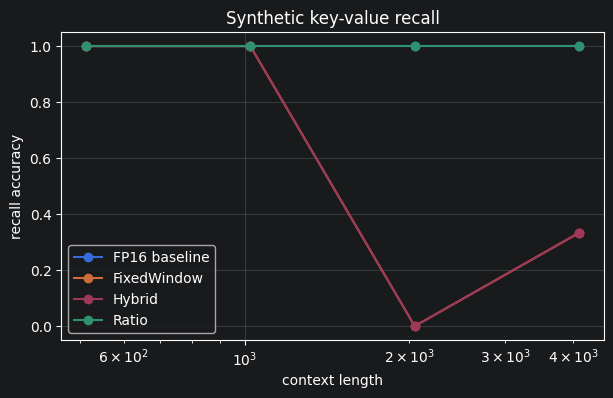

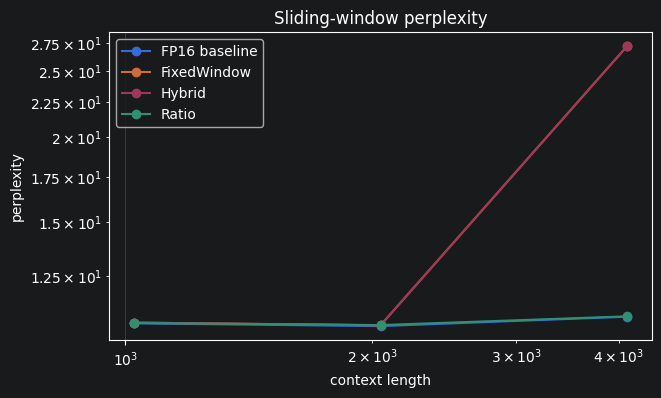

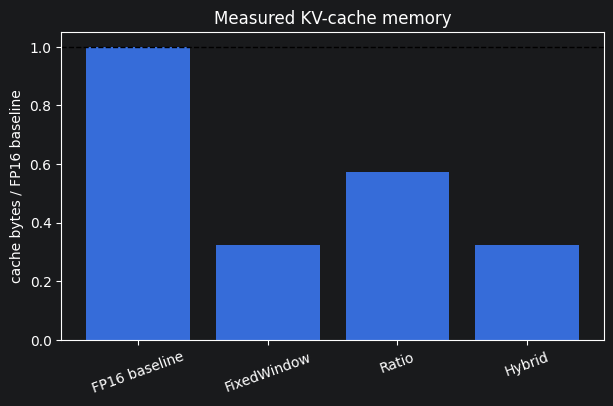

In [5]:
import matplotlib.pyplot as plt

if not recall_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, g in recall_df.groupby('strategy'):
        ax.plot(g['context_len'], g['accuracy'], marker='o', label=name)
    ax.set_xscale('log')
    ax.set_xlabel('context length')
    ax.set_ylabel('recall accuracy')
    ax.set_title('Synthetic key-value recall')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

if not ppl_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    for name, g in ppl_df.groupby('strategy'):
        ax.plot(g['context_len'], g['perplexity'], marker='o', label=name)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('context length')
    ax.set_ylabel('perplexity')
    ax.set_title('Sliding-window perplexity')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

if not mem_df.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(mem_df['strategy'], mem_df['ratio_to_baseline'])
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel('cache bytes / FP16 baseline')
    ax.set_title('Measured KV-cache memory')
    ax.tick_params(axis='x', rotation=20)
    plt.show()

## Optional Needle-In-A-Haystack

Run this after the main benchmark is sane. It is slower and more variable than recall/perplexity.

In [7]:
# Optional: uncomment to run NIAH locally.
niah_result = run_benchmark(
    PROFILE,
    device=DEVICE,
    run_recall=False,
    run_perplexity=False,
    run_niah=True,
    run_memory=False,
    output_dir=Path('results/local_niah'),
)
print(niah_result.get('output_path'))

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


results/local_niah/local_1777795937.json


## Autoresearch Tuning

Use this once the basic notebook produces non-zero quantized recall. `run_trial.py` runs one reproducible trial; `tune_policies.py` is the multi-hour local tuning loop.

In [8]:
# Optional commands. Uncomment one.
# !python autoresearch/run_trial.py --profile local --quick
# !CUDA_VISIBLE_DEVICES=0 python autoresearch/tune_policies.py --profile local --hours 3

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:00<00:00,  2.36it/s]
/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:629: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:634: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/npk/Projects/tiered_kv/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:651: UserWarning: `do_sample` is set to `False`. 